In [55]:
import pandas as pd

df_titanic = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')
df_titanic.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

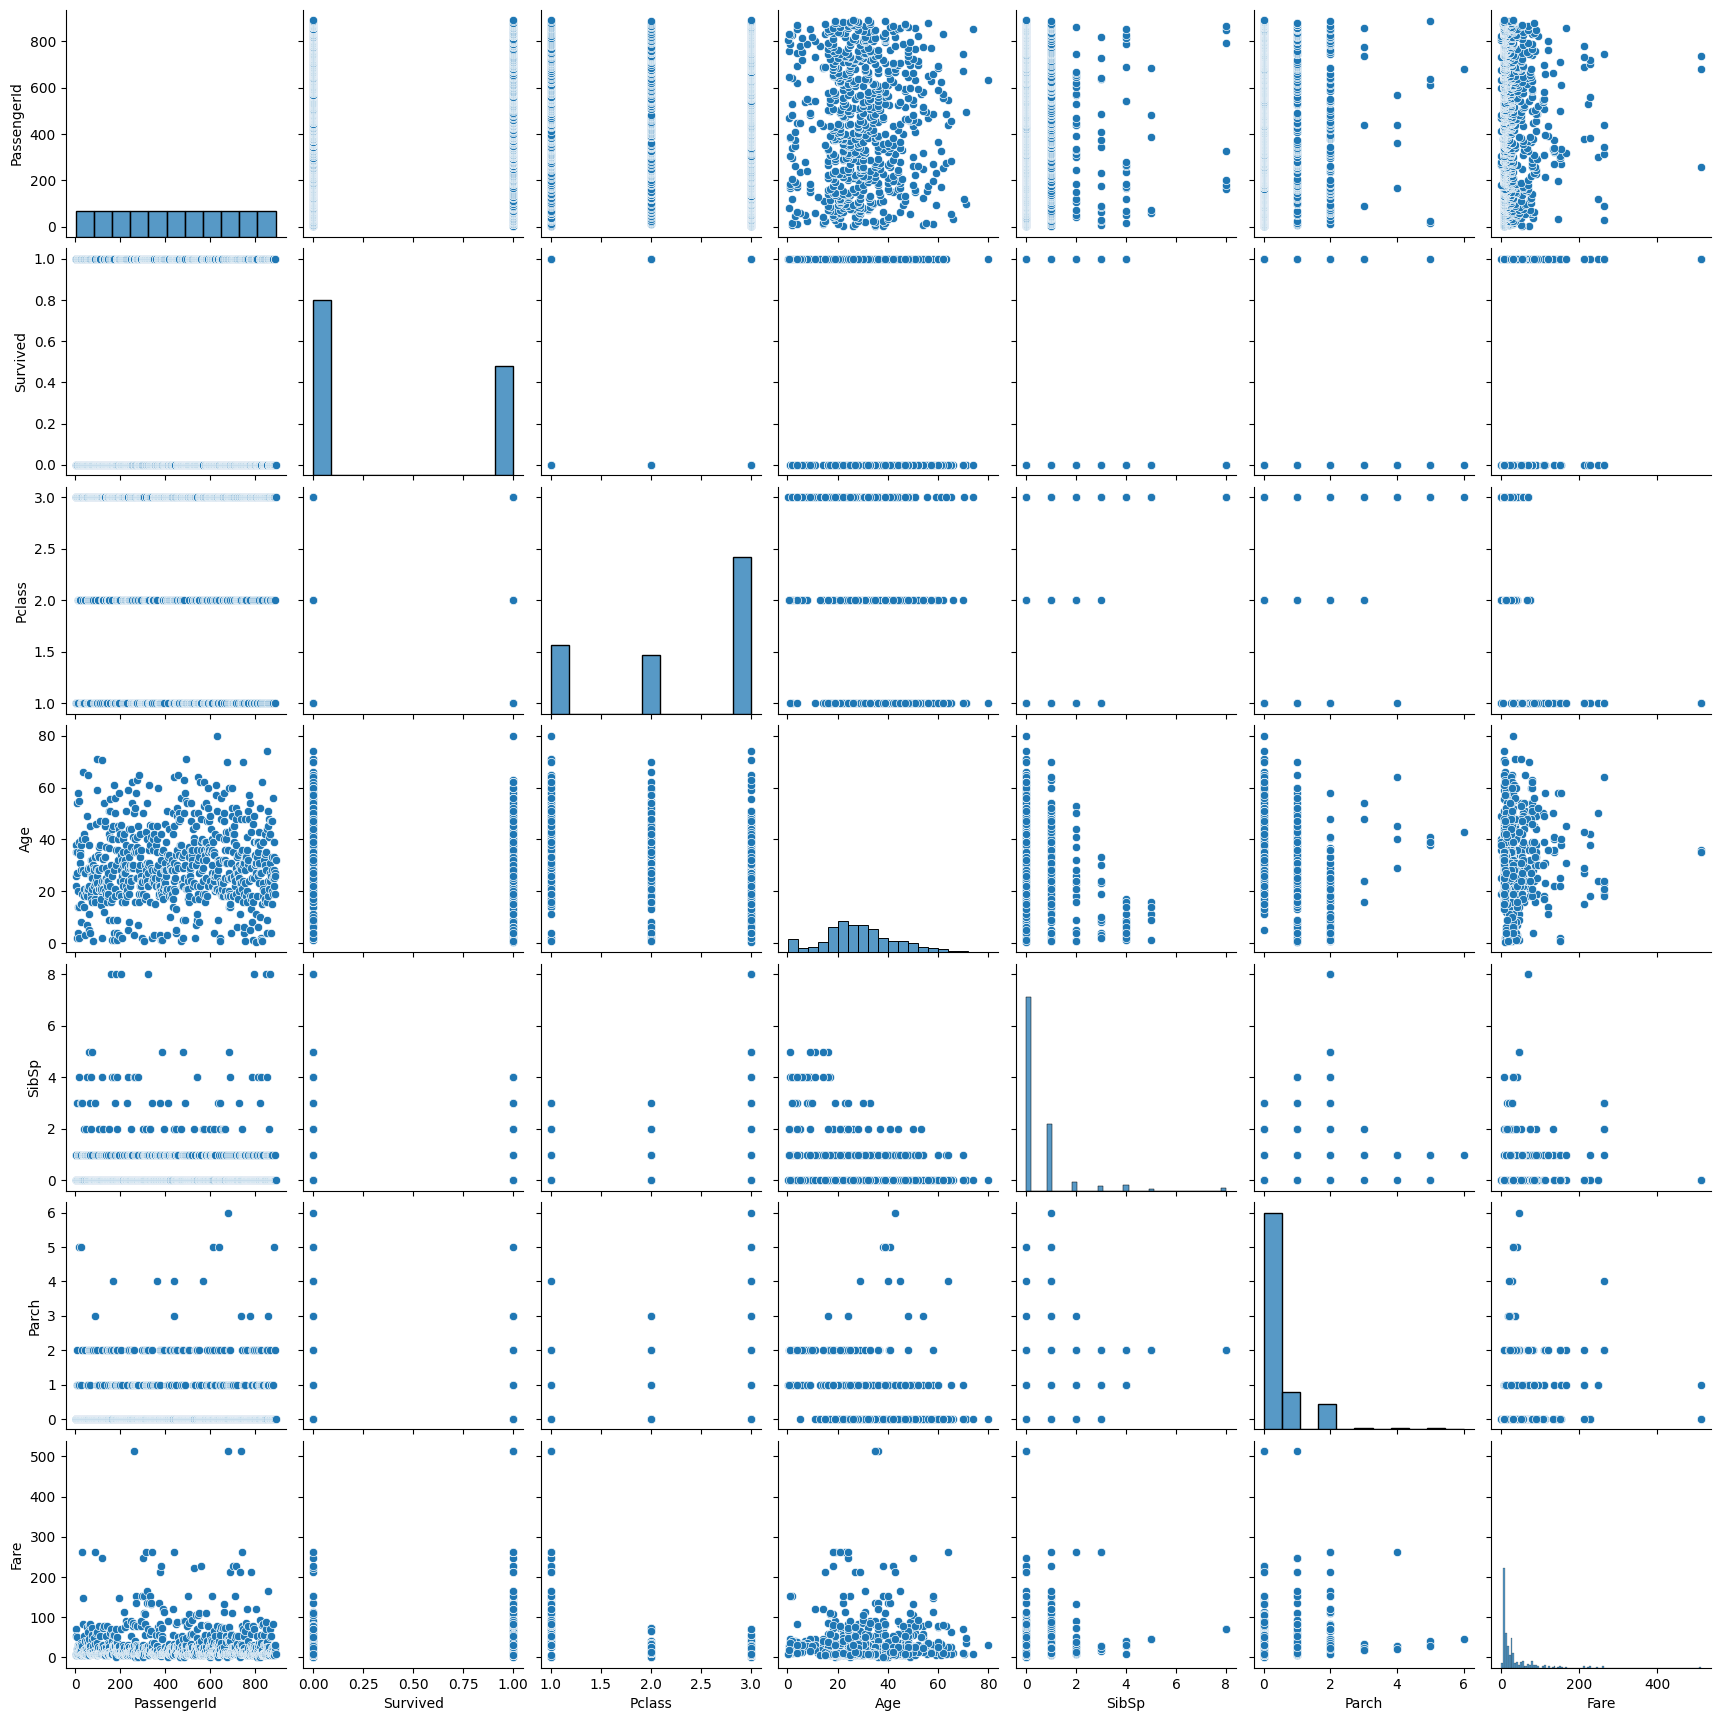

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.pairplot(df_numbers)

<Axes: xlabel='Pclass', ylabel='Survived'>

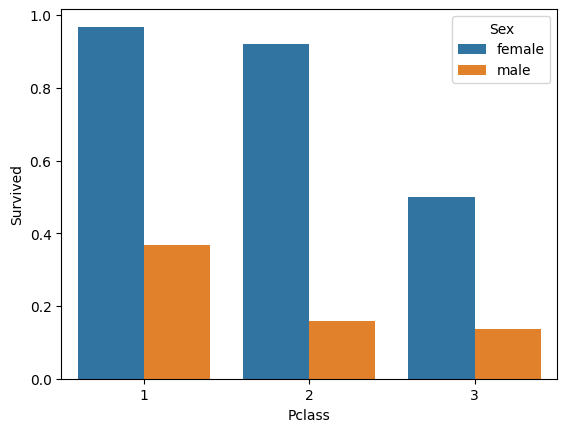

In [47]:
survival = df_titanic.groupby(['Sex','Pclass'])['Survived'].mean().reset_index()
sns.barplot(data=survival, x='Pclass', y='Survived',hue='Sex')

In [57]:
df_titanic['Age'].isnull().sum()

177

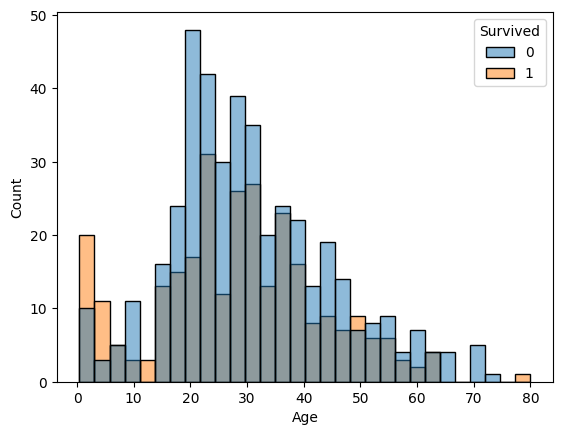

In [58]:
df_titanic_clean = df_titanic.dropna(subset=['Age']).reset_index(drop=True)
sns.histplot(data=df_titanic_clean, x='Age', hue='Survived', bins=30)
plt.show()

In [54]:
df_titanic_clean = df_titanic.dropna(subset=['Age']).reset_index(drop=True)
df_titanic_clean['Age'].isnull().sum()

0

In [59]:
df_titanic_clean.corr(numeric_only=True)['Survived'].sort_values()

Pclass        -0.359653
Age           -0.077221
SibSp         -0.017358
PassengerId    0.029340
Parch          0.093317
Fare           0.268189
Survived       1.000000
Name: Survived, dtype: float64

In [60]:
pd.get_dummies(df_titanic_clean, columns=['Pclass'])

,PassengerId,Survived,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_1,Pclass_2,Pclass_3
0,1,0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,False,False,True
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,True,False,False
2,3,1,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,False,False,True
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,True,False,False
4,5,0,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,886,0,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,NaN,Q,False,False,True
710,887,0,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,False,True,False
711,888,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,True,False,False
712,890,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,True,False,False


In [62]:
# Titanic Exploratory Analysis
# Dataset: 891 passengers, 12 variables

# 1. Survival rate overall
print("Overall survival rate:", df_titanic['Survived'].mean().round(3))

# 2. By sex
print("\nSurvival by sex:")
print(df_titanic.groupby('Sex')['Survived'].mean().round(3))

# 3. By class
print("\nSurvival by class:")
print(df_titanic.groupby('Pclass')['Survived'].mean().round(3))

# 4. By sex and class
print("\nSurvival by sex and class:")
print(df_titanic.groupby(['Sex','Pclass'])['Survived'].mean().round(3))

Overall survival rate: 0.384

Survival by sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64

Survival by class:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64

Survival by sex and class:
Sex     Pclass
female  1         0.968
        2         0.921
        3         0.500
male    1         0.369
        2         0.157
        3         0.135
Name: Survived, dtype: float64


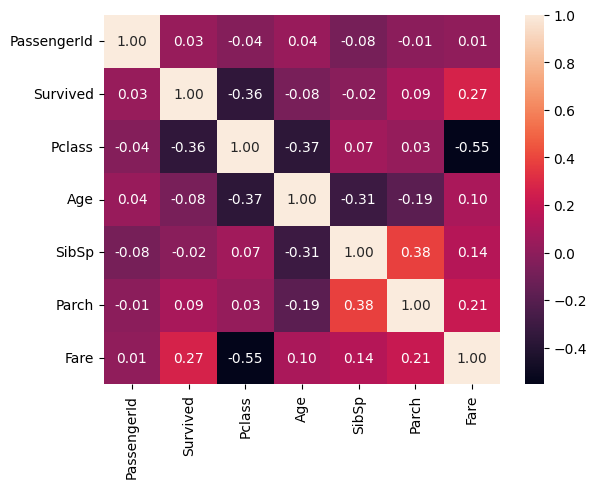

In [63]:
sns.heatmap(df_titanic_clean.corr(numeric_only=True), annot=True, fmt='.2f')
plt.show()

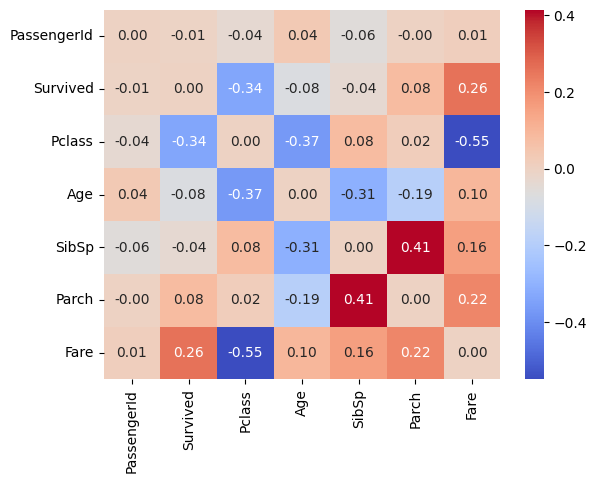

In [72]:
import numpy as np

corr = df_titanic.corr(numeric_only=True)
np.fill_diagonal(corr.values, 0)
sns.heatmap(corr, annot=True, fmt='.2f',cmap='coolwarm')
plt.show()

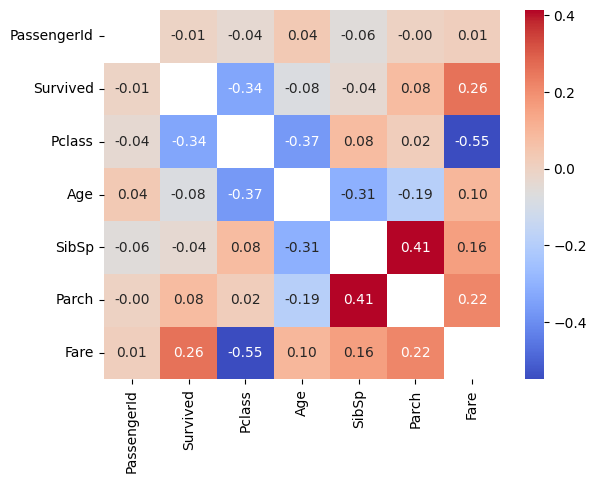

In [74]:
corr = df_titanic.corr(numeric_only=True)
mask = np.eye(len(corr), dtype=bool)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask)
plt.show()